In [1]:
from sklearn.datasets import load_diabetes

## 1. Loading DataSet and Creating Dataframe

In [2]:
dataset = load_diabetes()
dataset 

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [3]:
print(dataset["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

## 2. Creating X and y; no need for data preprocessing as its a clean data.

In [4]:
import pandas as pd

# Make a dataframe of independent features.
X = pd.DataFrame(dataset.data, columns=['age',
  'sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
# Make df of target varaible.

y=pd.DataFrame(dataset.target, columns=["target"])
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


## 3. Train Test Split

In [6]:
## Train-test split
from sklearn.model_selection import  train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

## 5.  Model Creation and Training

In [21]:
from sklearn.tree import  DecisionTreeRegressor
regressor=DecisionTreeRegressor()

regressor.fit(X_train,y_train)

print("Initial Train Score:")
print(regressor.score(X_train,y_train))
print("Initial Test Score:")
print(regressor.score(X_test,y_test))

Initial Train Score:
1.0
Initial Test Score:
-0.02411792792397116


## 6. Hyperparamter tuning

In [8]:
params = {
    'criterion':["squared_error", "friedman_mse", "absolute_error", "poisson"],
    'splitter':["best","random"],
    'max_depth':[1,2,3,4,5,10.15,20,25],
    'max_features':["auto","sqrt","log2"]
}

In [9]:
from sklearn.model_selection import  GridSearchCV
grid=GridSearchCV(regressor,param_grid=params,cv=5,scoring="neg_root_mean_squared_error")

In [10]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10.15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_root_mean_squared_error')

In [11]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 3,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [12]:
grid.best_score_

np.float64(-64.23781761893328)

In [13]:
best_features_model=DecisionTreeRegressor(criterion='friedman_mse',
 max_depth=3,
 max_features='sqrt',
 splitter='best')

In [14]:
best_features_model.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      max_features='sqrt')

In [15]:
# Visualize Deicison Tree

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import  tree

[Text(0.5, 0.875, 'x[2] <= 0.005\nfriedman_mse = 6148.282\nsamples = 309\nvalue = 153.903'),
 Text(0.25, 0.625, 'x[5] <= 0.032\nfriedman_mse = 3636.316\nsamples = 183\nvalue = 118.355'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[6] <= -0.034\nfriedman_mse = 3295.265\nsamples = 150\nvalue = 110.96'),
 Text(0.0625, 0.125, 'friedman_mse = 4156.039\nsamples = 19\nvalue = 156.474'),
 Text(0.1875, 0.125, 'friedman_mse = 2826.398\nsamples = 131\nvalue = 104.359'),
 Text(0.375, 0.375, 'x[8] <= 0.056\nfriedman_mse = 3808.029\nsamples = 33\nvalue = 151.97'),
 Text(0.3125, 0.125, 'friedman_mse = 3591.493\nsamples = 29\nvalue = 142.759'),
 Text(0.4375, 0.125, 'friedman_mse = 303.188\nsamples = 4\nvalue = 218.75'),
 Text(0.75, 0.625, 'x[2] <= 0.073\nfriedman_mse = 5295.789\nsamples = 126\nvalue = 205.532'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[6] <= -0.064\nfriedman_mse = 4653.159\nsamples = 101\nvalue = 189.297'),
 Text(0.5625, 0.125, 'friedman_mse = 2938.76\nsamples = 

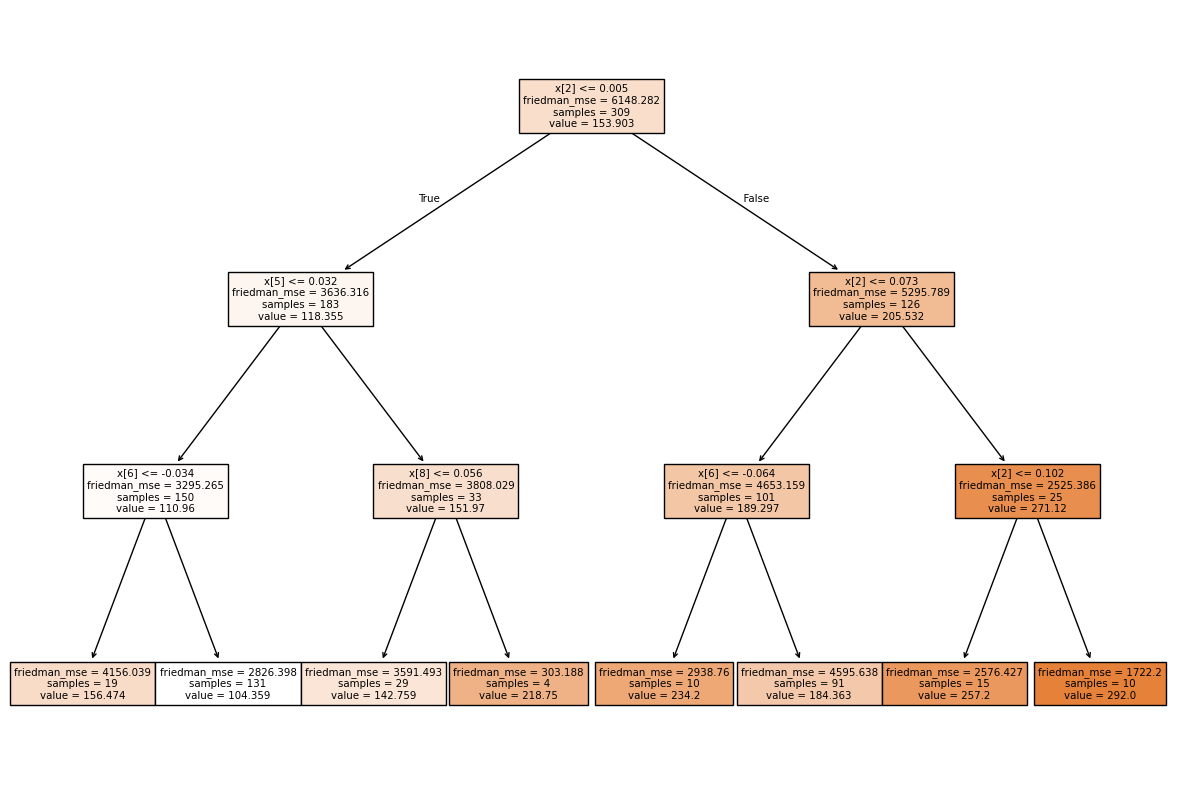

In [16]:
plt.figure(figsize=(15,10))
tree.plot_tree(best_features_model,filled=True)

In [17]:
# Train score
best_features_model.score(X_train,y_train)


0.4430796202714047

In [18]:
# Test score
best_features_model.score(X_test,y_test)

0.2725516180391824